**Problem Statement and Goal**
Heart Disease Prediction model is a very usefull model. Without this model, a doctor take much time to analyse the heart disease of the patient. So we create the model that helps the doctor to analyse and predict the heart disease.

In [1]:
import pandas as pd    #importing pandas
import numpy as np     #importing numpy
import matplotlib.pyplot as plt    #importing matplotlib.pyplot
import seaborn as sns     #importing seaborn as sns
#here I import train_test_spit from sklearn.model_selection that is used to split the dataset
from sklearn.model_selection import train_test_split    
#here I import the logistic Regression from sklearn.linear model
from sklearn.linear_model import LogisticRegression
#here I import the accuracy_score, confusion_matrix, roc_curve and auc from sklearn.metrics that is used to check the performance of the model
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

**Dataset Loading and Preprocessing**
Dataset is uploaded and then clean and prepare the data for the model training so that the can train himself on that data and perform very well.

In [2]:
#here I read the dataset using pandas
Heart_data = pd.read_csv("archive.zip")     

In [3]:
# here I use the iloc to see the dataset in integer location
Heart_data.iloc[:]

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,Male,Atypical angina,140,221,Lower than 120 mg/ml,ST-T wave abnormality,164,Yes,0.0,Downsloping,Zero,Fixed Defect,1
1021,60,Male,Typical angina,125,258,Lower than 120 mg/ml,Normal,141,Yes,2.8,Flat,One,Reversable Defect,0
1022,47,Male,Typical angina,110,275,Lower than 120 mg/ml,Normal,118,Yes,1.0,Flat,One,Fixed Defect,0
1023,50,Female,Typical angina,110,254,Lower than 120 mg/ml,Normal,159,No,0.0,Downsloping,Zero,Fixed Defect,1


In [4]:
#here I find that the dataset have some empty boxes or not
Heart_data.isnull().sum()

age                              0
sex                              0
chest_pain_type                  0
resting_blood_pressure           0
cholestoral                      0
fasting_blood_sugar              0
rest_ecg                         0
Max_heart_rate                   0
exercise_induced_angina          0
oldpeak                          0
slope                            0
vessels_colored_by_flourosopy    0
thalassemia                      0
target                           0
dtype: int64

In [5]:
#here I find the shape of the dataset
Heart_data.shape

(1025, 14)

In [6]:
#here I see the names of the columns of the dataset
Heart_data.columns

Index(['age', 'sex', 'chest_pain_type', 'resting_blood_pressure',
       'cholestoral', 'fasting_blood_sugar', 'rest_ecg', 'Max_heart_rate',
       'exercise_induced_angina', 'oldpeak', 'slope',
       'vessels_colored_by_flourosopy', 'thalassemia', 'target'],
      dtype='object')

In [7]:
#here I get the information about the dataset
Heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1025 non-null   int64  
 1   sex                            1025 non-null   object 
 2   chest_pain_type                1025 non-null   object 
 3   resting_blood_pressure         1025 non-null   int64  
 4   cholestoral                    1025 non-null   int64  
 5   fasting_blood_sugar            1025 non-null   object 
 6   rest_ecg                       1025 non-null   object 
 7   Max_heart_rate                 1025 non-null   int64  
 8   exercise_induced_angina        1025 non-null   object 
 9   oldpeak                        1025 non-null   float64
 10  slope                          1025 non-null   object 
 11  vessels_colored_by_flourosopy  1025 non-null   object 
 12  thalassemia                    1025 non-null   o

In [8]:
# here I see the first five records of the dataset
Heart_data.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0


In [9]:
#here I find the last five records of the dataset
Heart_data.tail()

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
1020,59,Male,Atypical angina,140,221,Lower than 120 mg/ml,ST-T wave abnormality,164,Yes,0.0,Downsloping,Zero,Fixed Defect,1
1021,60,Male,Typical angina,125,258,Lower than 120 mg/ml,Normal,141,Yes,2.8,Flat,One,Reversable Defect,0
1022,47,Male,Typical angina,110,275,Lower than 120 mg/ml,Normal,118,Yes,1.0,Flat,One,Fixed Defect,0
1023,50,Female,Typical angina,110,254,Lower than 120 mg/ml,Normal,159,No,0.0,Downsloping,Zero,Fixed Defect,1
1024,54,Male,Typical angina,120,188,Lower than 120 mg/ml,ST-T wave abnormality,113,No,1.4,Flat,One,Reversable Defect,0


In [10]:
#here I find that the dataset have duplicate records or not
Heart_data.duplicated().sum()

723

In [11]:
#here I remove the duplicate records of the dataset
Heart_data = Heart_data.drop_duplicates()

In [12]:
#here I again check that the dataset have duplicate or not
Heart_data.duplicated().sum()

0

In [13]:
#here I find the statistic summary of the dataset
Heart_data.describe()

,age,resting_blood_pressure,cholestoral,Max_heart_rate,oldpeak,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,131.602649,246.500000,149.569536,1.043046,0.543046
std,9.04797,17.563394,51.753489,22.903527,1.161452,0.498970
min,29.00000,94.000000,126.000000,71.000000,0.000000,0.000000
25%,48.00000,120.000000,211.000000,133.250000,0.000000,0.000000
50%,55.50000,130.000000,240.500000,152.500000,0.800000,1.000000
75%,61.00000,140.000000,274.750000,166.000000,1.600000,1.000000
max,77.00000,200.000000,564.000000,202.000000,6.200000,1.000000


In [14]:
#here I see that how many patient have heart disease in the dataset and how many have not
Heart_data["target"].value_counts()

target
1    164
0    138
Name: count, dtype: int64

**Data Visualiztion and Exploration**
In this part I analyse the data through graphs called visualization and explore the data how the data is. In this part, we come to know that: is the data best for model to perform very well.

<Axes: xlabel='target'>

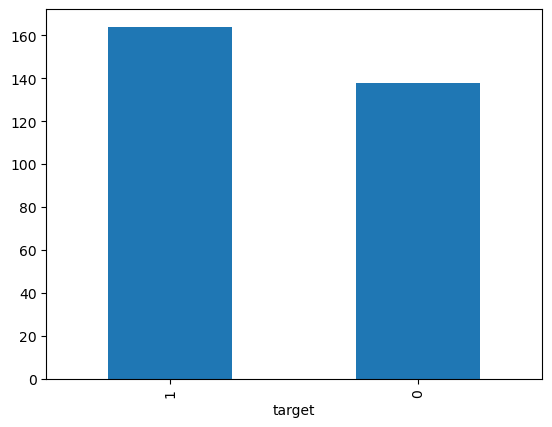

In [15]:
#here I see that how many patient have heart disease in the dataset and how many have not through bar plot
Heart_data["target"].value_counts().plot(kind="bar")

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'resting_blood_pressure'}>],
       [<Axes: title={'center': 'cholestoral'}>,
        <Axes: title={'center': 'Max_heart_rate'}>],
       [<Axes: title={'center': 'oldpeak'}>,
        <Axes: title={'center': 'target'}>]], dtype=object)

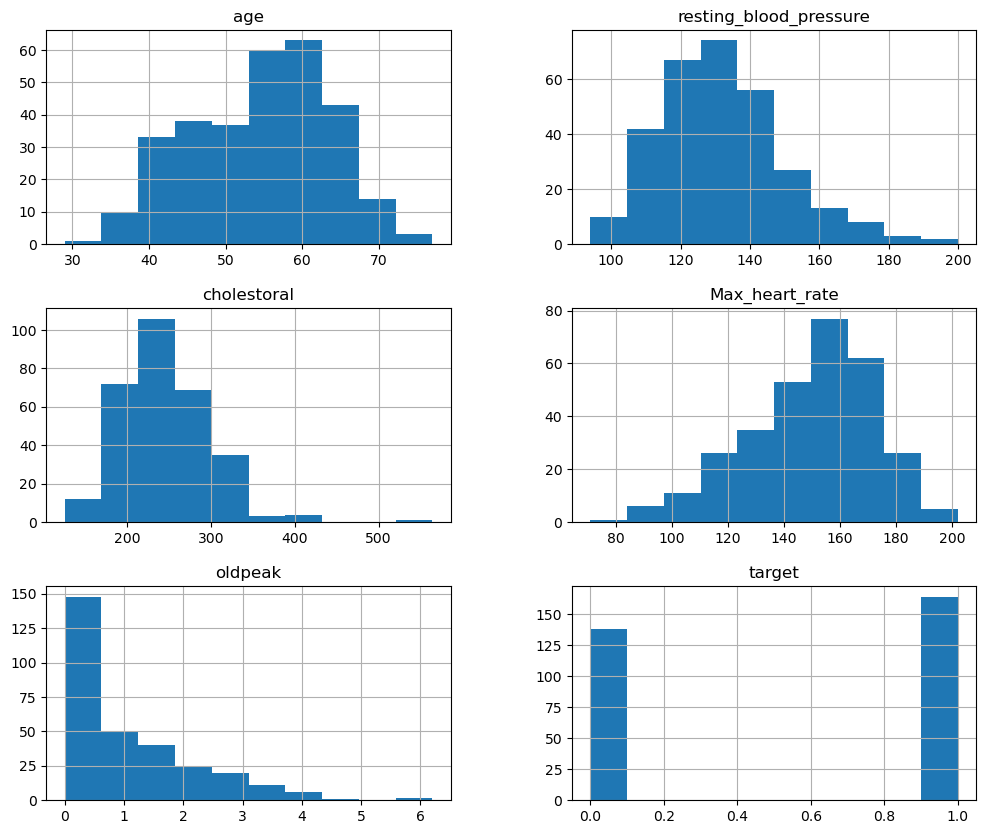

In [16]:
#here I show the histogram
Heart_data.hist(figsize=(12,10))

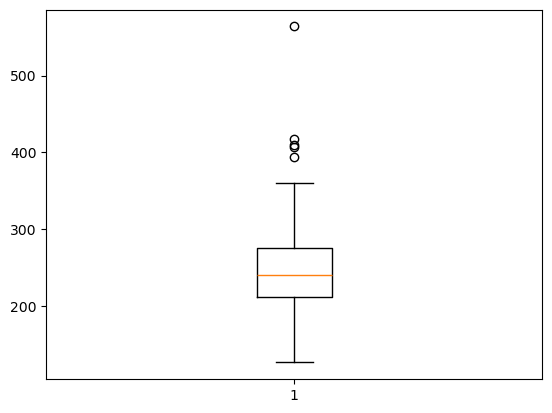

In [17]:
#here I analyse the cholestoral column of the dataset throgh box plot
plt.boxplot(Heart_data["cholestoral"])
plt.show()

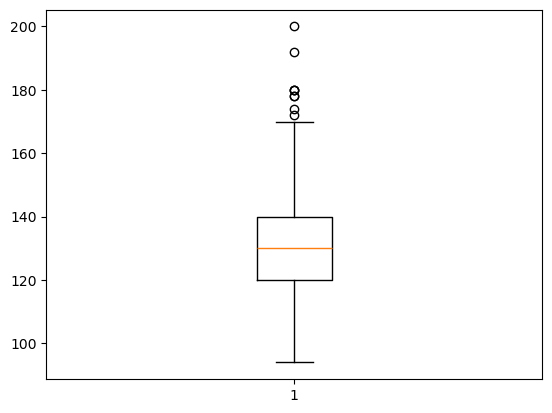

In [18]:
#here I analyse the resting_blood_pressure column of the dataset throgh box plot
plt.boxplot(Heart_data["resting_blood_pressure"])
plt.show()

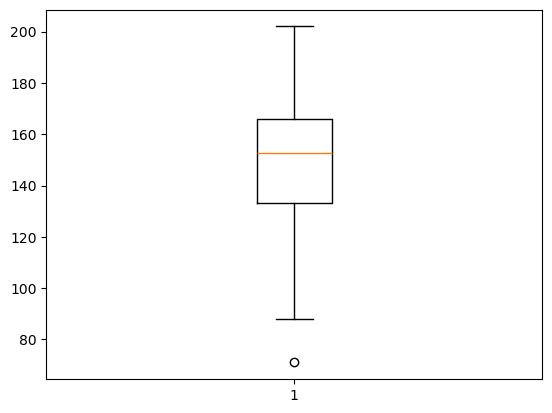

In [19]:
#here I analyse the max heart rate column of the dataset throgh box plot
plt.boxplot(Heart_data["Max_heart_rate"])
plt.show()

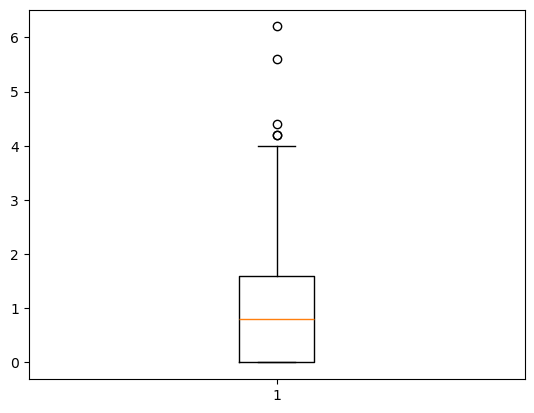

In [20]:
#here I analyse the oldpeak column of the dataset throgh box plot
plt.boxplot(Heart_data["oldpeak"])
plt.show()

<Axes: xlabel='sex', ylabel='count'>

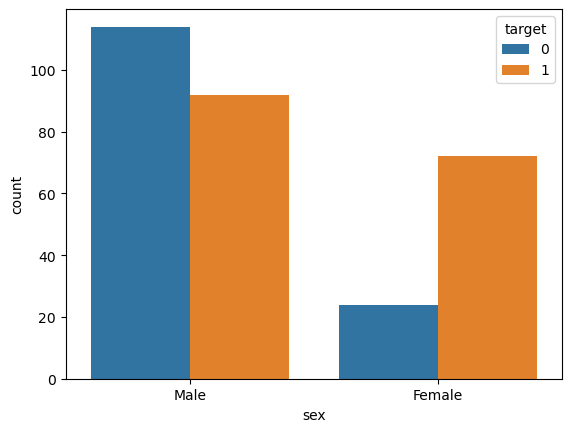

In [21]:
#here I analyse that how many males and females are affected by the heart disease and how many are not through count plot
sns.countplot(x="sex", hue="target", data=Heart_data)

In [22]:
#here I find the correleation
corr = Heart_data.corr
corr

<bound method DataFrame.corr of      age     sex   chest_pain_type  resting_blood_pressure  cholestoral  \
0     52    Male    Typical angina                     125          212   
1     53    Male    Typical angina                     140          203   
2     70    Male    Typical angina                     145          174   
3     61    Male    Typical angina                     148          203   
4     62  Female    Typical angina                     138          294   
..   ...     ...               ...                     ...          ...   
723   68  Female  Non-anginal pain                     120          211   
733   44  Female  Non-anginal pain                     108          141   
739   52    Male    Typical angina                     128          255   
843   59    Male      Asymptomatic                     160          273   
878   54    Male    Typical angina                     120          188   

        fasting_blood_sugar               rest_ecg  Max_heart_rate 

In [23]:
#here I convert the other forms of data into numerical form
Heart_data = pd.get_dummies(Heart_data,columns = ["sex","chest_pain_type", "fasting_blood_sugar", "rest_ecg", "exercise_induced_angina", "slope", "vessels_colored_by_flourosopy", "thalassemia"])

In [24]:
Heart_data.iloc[:]

,age,resting_blood_pressure,cholestoral,Max_heart_rate,oldpeak,target,sex_Female,sex_Male,chest_pain_type_Asymptomatic,chest_pain_type_Atypical angina,...,slope_Upsloping,vessels_colored_by_flourosopy_Four,vessels_colored_by_flourosopy_One,vessels_colored_by_flourosopy_Three,vessels_colored_by_flourosopy_Two,vessels_colored_by_flourosopy_Zero,thalassemia_Fixed Defect,thalassemia_No,thalassemia_Normal,thalassemia_Reversable Defect
0,52,125,212,168,1.0,0,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
1,53,140,203,155,3.1,0,False,True,False,False,...,True,False,False,False,False,True,False,False,False,True
2,70,145,174,125,2.6,0,False,True,False,False,...,True,False,False,False,False,True,False,False,False,True
3,61,148,203,161,0.0,0,False,True,False,False,...,False,False,True,False,False,False,False,False,False,True
4,62,138,294,106,1.9,0,True,False,False,False,...,False,False,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,68,120,211,115,1.5,1,True,False,False,False,...,False,False,False,False,False,True,True,False,False,False
733,44,108,141,175,0.6,1,True,False,False,False,...,False,False,False,False,False,True,True,False,False,False
739,52,128,255,161,0.0,0,False,True,False,False,...,False,False,True,False,False,False,False,False,False,True
843,59,160,273,125,0.0,0,False,True,True,False,...,False,False,False,False,False,True,True,False,False,False


**Model Training and Evaluation**
In this part, we train the model on data and then see how the model is performing. Is model performing well or not.

In [25]:
#here I split the data into two parts x and y
X = Heart_data.drop("target", axis = 1)
Y = Heart_data["target"]

In [26]:
#here I split the dataset into parts train and test
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [27]:
#here I create the instance of the model
model = LogisticRegression(max_iter = 2000, random_state=42)

In [28]:
#here I train the model
model.fit(X_train, y_train)

LogisticRegression(max_iter=2000, random_state=42)

In [29]:
#here I get the prediction of the model on the test data
y_pred = model.predict(X_test)

In [30]:
#here I get the probability of the model prediction on the test data
y_pred_prob = model.predict_proba(X_test)

In [31]:
#here I find the accuracy
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.819672131147541

In [32]:
#here I use confusion matrix to analyse the model performance
confusion_matrix = confusion_matrix(y_test, y_pred)

In [33]:
confusion_matrix

array([[25,  7],
       [ 4, 25]], dtype=int64)

*Here I analyse the model through roc curve*

In [34]:
y_pred_prob_positive = y_pred_prob[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_positive)

In [35]:
roc_auc = auc (fpr, tpr)

In [36]:
roc_auc

0.8599137931034483

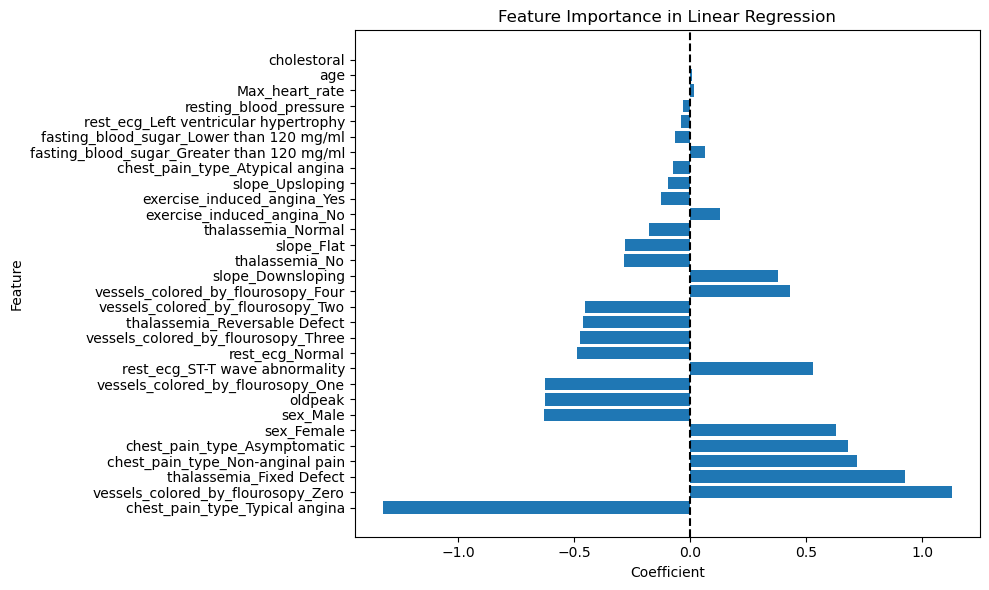

                                       Feature  Coefficient  Absolute
10              chest_pain_type_Typical angina    -1.323050  1.323050
25          vessels_colored_by_flourosopy_Zero     1.125920  1.125920
26                    thalassemia_Fixed Defect     0.924128  0.924128
9             chest_pain_type_Non-anginal pain     0.717271  0.717271
7                 chest_pain_type_Asymptomatic     0.681659  0.681659
5                                   sex_Female     0.630009  0.630009
6                                     sex_Male    -0.628638  0.628638
4                                      oldpeak    -0.626037  0.626037
22           vessels_colored_by_flourosopy_One    -0.624070  0.624070
15              rest_ecg_ST-T wave abnormality     0.530104  0.530104
14                             rest_ecg_Normal    -0.487539  0.487539
23         vessels_colored_by_flourosopy_Three    -0.476584  0.476584
29               thalassemia_Reversable Defect    -0.462222  0.462222
24           vessels

In [37]:
#here I make a function that is used to analyse the effect of each feature on the result
def plot_linear_model_features(model, X):
    feature_names = X.columns
    coefficients_values = model.coef_[0] if model.coef_.ndim > 1 else model.coef_
    coefficients = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coefficients_values
    })
    coefficients['Absolute'] = coefficients['Coefficient'].abs()
    coefficients = coefficients.sort_values('Absolute', ascending=False)
    plt.figure(figsize=(10, 6))
    plt.barh(coefficients['Feature'], coefficients['Coefficient'])
    plt.xlabel('Coefficient')
    plt.ylabel('Feature')
    plt.title('Feature Importance in Linear Regression')
    plt.axvline(x=0, color='k', linestyle='--')
    plt.tight_layout()
    plt.show()
    return coefficients
important_features = plot_linear_model_features(model, X)
print(important_features)

**Results and Final Insights**
In results, our model is performing well with a best accuracy. In final insights, machine learning is effective and early detection is possible and model performance also depend on the data.